# Notebook for Testing Mask Values for Data

## Import Necessary Packages

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

import trxrd


%matplotlib widget

## Define Experimental Parameters

In [73]:
# Experimental Parameters and Defaults

# ============================================================
# Data and Mask Paths, Scan Name, and Filename Pattern
# ============================================================
DATA_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3_Static_TempDep2") # Path to directory containing TIFF files
MASK_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif") # Path to mask file
SCAN_NAME = "BTO400S3_staticTdep360K" # Prefix in file name to identify relevant files, e.g. "550nm_re" etc.
SCAN_TYPE = "delay_scan" # Type of scan based on filename pattern, e.g. "delay_scan", "theta_samz", etc. Must correspond to a key in the "filename_patterns" dictionary in trxrd.py
BACKGROUND_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BlankSubstratePinkBeam\blanksubstratePinkBeam285K-1.0fshw-3e-09delay00003_044.tif")
SAVE_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_Temp_Data")
# PONI file from pyFAI-calib2. Set to a Path to use PONI geometry;
# set to None to use the manual parameters below.
PONI_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\poni_files\CeO2_calib_poni.poni")              # Path to .poni file, or None
# ============================================================
# General Defaults
# ============================================================
FIGSIZE = (10, 4)
STD_FACTOR = 3
MAX_PROCESSORS = 4
DELAY_SIGN = -1 # Check file naming scheme, sometimes positives delays have "-" in front and negative have no sign so need to invert sign

# ============================================================
# Beam Stop Mask Defaults
# ============================================================
MASK_CENTER_X = 52
MASK_CENTER_Y = 1667
MASK_RADIUS = 30

# ============================================================
# Center Guess and Sampling Defaults
# ============================================================
CENTER_X = 44
CENTER_Y = 1666
DOWNSAMPLE = 2 # Downsample factor for center finding, e.g. 2 means use every other pixel, 4 means use every 4th pixel, etc.

# ============================================================
# Detector Parameters and Defaults
# ============================================================
META_PATH = None
# Detector and beam parameters
PIXEL1 = 1.72e-4                 # m, detector pixel size along rows (y)
PIXEL2 = 1.72e-4                 # m, detector pixel size along cols (x)
DISTANCE = 0.1723                 # m, sample-to-detector distance
WAVELENGTH = 0.39738514824147314e-10          # m

# Detector orientation
TILT_ANGLE = np.deg2rad(0)               # rad
TILT_PLANE_ROTATION = np.deg2rad(90)      # rad
ROT3 = 0.0                      # rad, in-plane detector rotation

# Optional corrections
POLARIZATION_FACTOR = 0.999      # e.g. 0.99 or None
DARK = None                     # 2D dark image or None
FLAT = None                     # 2D flat-field image or None

# ============================================================
# Azimuthal Averaging and Normalization Defaults
# ============================================================
UNIT = "q_A^-1" # Unit for x-axis of azimuthally averaged data, e.g. "q_A^-1" for inverse Angstroms, "2theta_deg" for degrees, etc. 
NAN_MIN = 0.35 # Minimum value for valid data, values below this will be set to NaN, e.g. 0.35 or None for no minimum threshold
NAN_MAX = None # Maximum value for valid data, values above this will be set to NaN, e.g. 1.0 or None for no maximum threshold
NORM_MIN = 4.05 # Minimum value for normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
NORM_MAX = 4.25 # Maximum value for normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold
N_POINTS = 3000 # Number of points for azimuthal averaging, e.g. 3000 or None to use all pixels

# ============================================================
# Background Subtraction Defaults
# ============================================================
BACKGROUND_NORM_MIN = 1.0 # Minimum value for background normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
BACKGROUND_NORM_MAX = 1.5 # Maximum value for background normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold

# ============================================================
# Baseline Subtraction Defaults
# ============================================================
LAM_VAL = 1e4
P_VAL = 0.05

# ============================================================
# PDF Calcuation Defaults
# ============================================================
COMPOSITION = "BaTiO3" # Sample composition for form factor calculation, e.g. "BaTiO3" or None for no form factor correction
R_MAX = 20.0 # Maximum r value for PDF calculation, e.g. 20.0 or None for no maximum
N_R = 2000 # Number of r points for PDF calculation, e.g.
Q_MIN = 0.5 # Minimum q value for PDF calculation, e.g. 0.5 or None for no minimum
Q_MAX = 15.0 # Maximum q value for PDF calculation, e.g. 16.0 or None for no maximum
WINDOW = "lorch" # Window function for PDF calculation, e.g. "lorch", "hanning", "blackman", or None for no window
# ============================================================
# Optional Saving .dat Files
# ============================================================
SAVE_AZAV_DAT = True # Whether to save azimuthally averaged profiles as .dat files in addition to the .h5 file, e.g. True or False
# ============================================================
# Form Factor CSV File
# ============================================================
FORM_FACTOR_FILE = Path(
    r"C:\Users\lheald\Documents\Guzelturk_Lab\gued\packages\x_ray_ff\atomic_FF_coeffs_clean.csv"
)

## Define File Paths

In [74]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

10 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3_Static_TempDep2.
Using mask file: C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif


## Load Meta Data

In [75]:
# if META_PATH is not None:
#     metadata = trxrd.read_tif_metadata(META_PATH)
#     print(metadata.keys())
#     CENTER_X = metadata["center_x"]
#     CENTER_Y = metadata["center_y"]
#     DISTANCE = metadata["distance"]
#     WAVELENGTH = metadata["wavelength"]
#     POLARIZATION_FACTOR = metadata["polarization"]
#     PIXEL1 = 1.50e-4
#     PIXEL2 = 1.50e-4

## Import Images

In [76]:
data_dict = trxrd.get_images_by_scan_name(
    folder_path=DATA_PATH,
    scan_name=SCAN_NAME,
    sort=True,
    filter_data=False,
    plot=False,
)

print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)

10 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3_Static_TempDep2 with scan name BTO400S3_staticTdep360K.
dict_keys(['images', 'counts', 'file_names'])
Images shape: (10, 1679, 1475)
Counts shape: (10,)


## Build Combined Masks

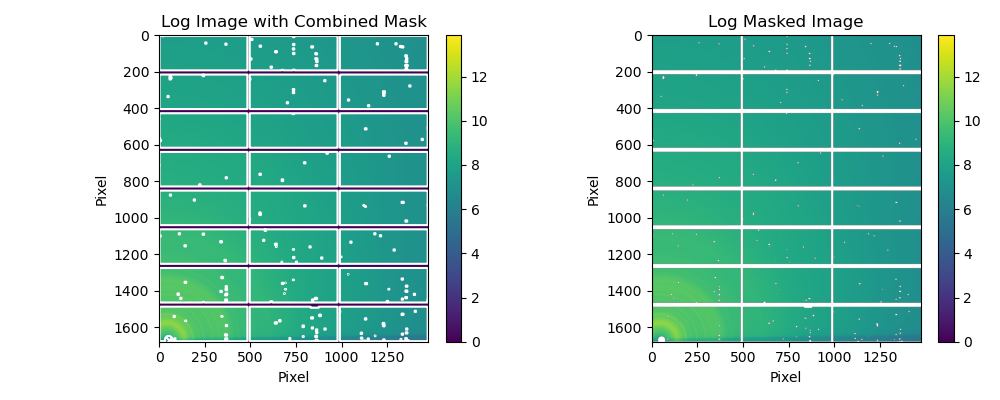

In [77]:
image_shape = data_dict["images"].shape[1:]   # (rows, cols)

combined_mask = trxrd.build_combined_mask(
    image_shape,
    center_xy = (MASK_CENTER_X, MASK_CENTER_Y),
    radius = 20,
    detector_mask=None,
    mask_path=MASK_FILE,
    plot=True,
    example_image=data_dict["images"][0],
)

## Find Centers for Images

In [14]:
center_result = trxrd.find_centers_in_stack_radial_parallel(
    data_array=data_dict["images"],
    center_guess_yx=(CENTER_Y, CENTER_X),   # note: (y, x)
    search_radius=10,
    center_mask=None,
    r_min=0,
    r_max=1400,
    downsample=1,
    intensity_threshold=None,
    top_percentile=60,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot_example=True,
    example_index=0,
    plot_center_vs_image=True,
)

centers = center_result["centers_xy"]
print("Centers shape:", centers.shape)
print("First center:", centers[0])
mean_center = np.mean(centers, axis=0)
print(f"Mean center: {mean_center}")


Finding centers for 4 images...


KeyboardInterrupt: 

## Compute Azimuthal Average

Using PONI file: C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\poni_files\CeO2_calib_poni.poni
Integrating 10 images...
  Completed 10/10 (100.0%)
Done integrating.
q shape: (3000,)
profiles shape: (10, 3000)


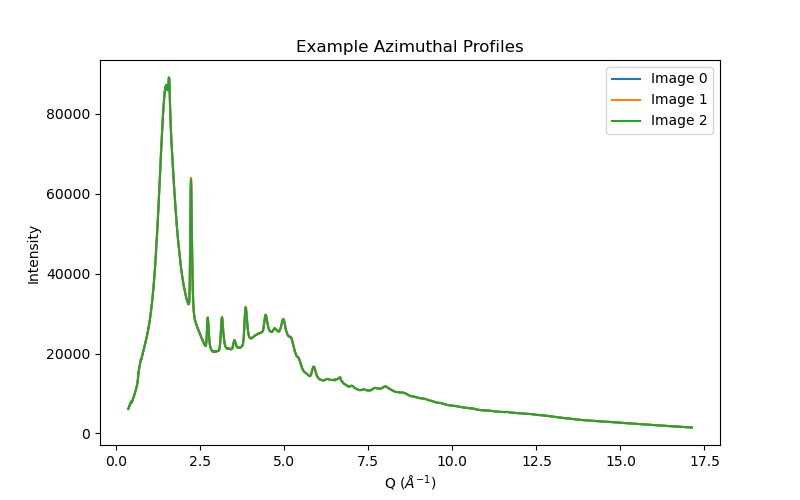

In [78]:
if PONI_FILE is not None:
    print(f"Using PONI file: {PONI_FILE}")
    az_result = trxrd.azimuthal_average_pyfai(
    images=data_dict["images"],
    centers_xy=None,   # note: (x, y)
    poni_path=PONI_FILE,
    npt=N_POINTS,
    unit=UNIT,
    nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
    azimuth_range=None,
    integration_mask=combined_mask,
    return_dict=True,
    progress_interval=100,
    use_custom_polarization=False,
    integration_function="integrate1d",
    correct_solid_angle=False,
    method=("bbox", "csr", "cython")
)
else:
    az_result = trxrd.azimuthal_average_pyfai(
        images=data_dict["images"],
        centers_xy=(CENTER_X, CENTER_Y),   # note: (x, y)
        polarization_factor=POLARIZATION_FACTOR,
        npt=N_POINTS,
        unit=UNIT,
        nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
        azimuth_range=None,
        integration_mask=combined_mask,
        return_dict=True,
        progress_interval=100,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        method=("bbox", "csr", "cython")
    )

q = az_result["radial"]
profiles = az_result["profiles"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)

plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, profiles[i], label=f"Image {i}")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Intensity")
plt.title("Example Azimuthal Profiles")
plt.legend()
plt.show()

## Normalize Azimuthal Averages

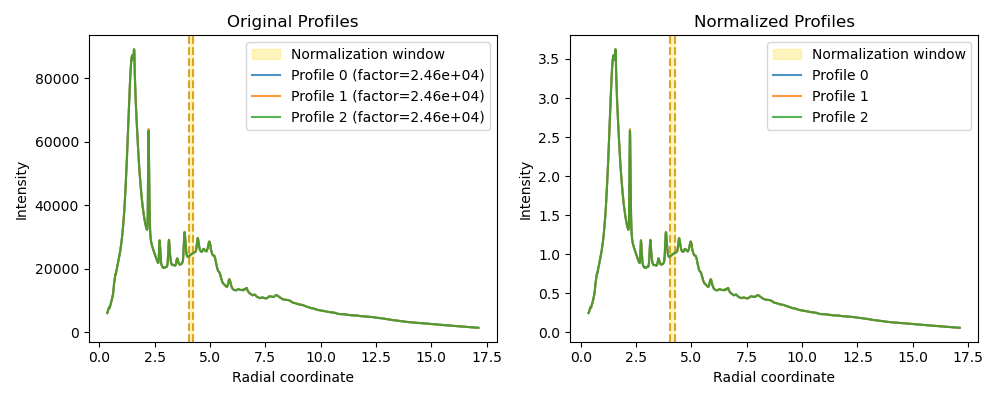

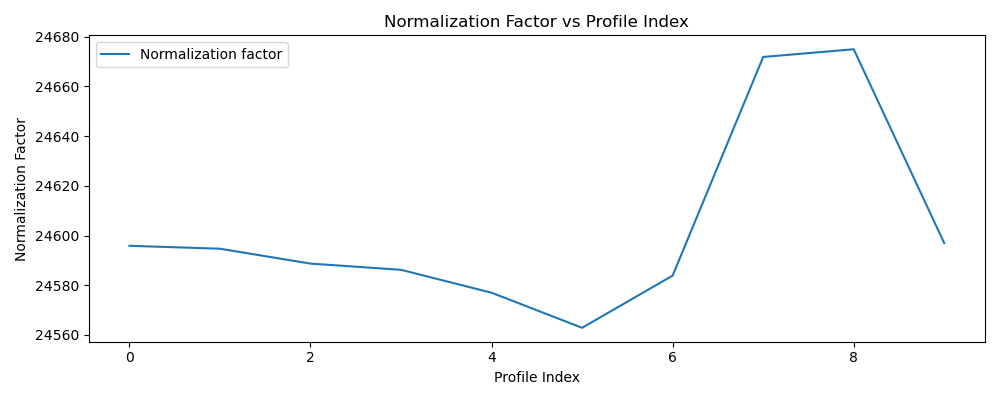

In [79]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(NORM_MIN, NORM_MAX),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 1, 2],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Load and Prepare Background Image(s)

Loading background from: \\s7data\beams46\7IDC\Cotts\2025_11Exp\BlankSubstratePinkBeam\blanksubstratePinkBeam285K-1.0fshw-3e-09delay00003_044.tif
dict_keys(['files', 'background_stack', 'background_mean', 'background_std', 'n_images'])
Background stack shape: (1, 1679, 1475)
Background mean shape: (1679, 1475)


C:\Users\lheald\AppData\Local\Temp\ipykernel_10448\2325887684.py:22: RuntimeWarning: Mean of empty slice
  bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


Using PONI geometry from file: C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\poni_files\CeO2_calib_poni.poni for background azimuthal average.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\normalization.py:266: RuntimeWarning: Mean of empty slice
  background_profile_mean = np.nanmean(background_profiles, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


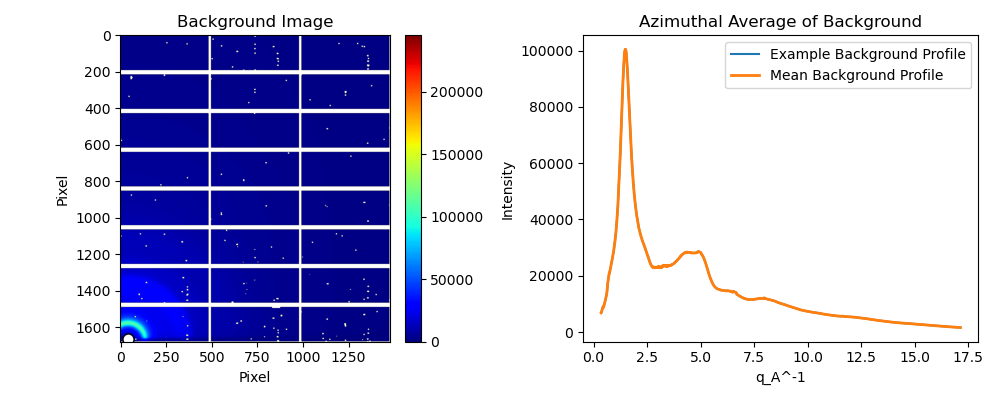

In [80]:
# Background path can be either:
# - a single tif file
# - or a folder containing many background tif files
# Load Data
print(f"Loading background from: {BACKGROUND_PATH}")
bg_dict = trxrd.load_background(
    background_path=BACKGROUND_PATH,
    sort=True,
    plot=False,
)

print(bg_dict.keys())
print("Background stack shape:", bg_dict["background_stack"].shape)
print("Background mean shape:", bg_dict["background_mean"].shape)

bg_dict["background_stack"] = trxrd.apply_mask_from_bool(
    data_array=bg_dict["background_stack"],
    mask_bool=combined_mask,
)


bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# Compute background azimuthal average
if PONI_FILE is not None:
    print(f"Using PONI geometry from file: {PONI_FILE} for background azimuthal average.")
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=None,   # one average center in (x, y)
        poni_path=PONI_FILE,
        npt=N_POINTS,
        unit=UNIT,
        nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
        azimuth_range=None,
        integration_mask=combined_mask,
        return_dict=True,
        progress_interval=100,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )
else:
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=(CENTER_X, CENTER_Y),   # one average center in (x, y)
        unit=UNIT,
        polarization_factor=POLARIZATION_FACTOR,
        npt=N_POINTS,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )

q_bg = bg_az_result["radial"]
background_profile = bg_az_result["background_profile_mean"]



## Subtract Scaled Background from Images

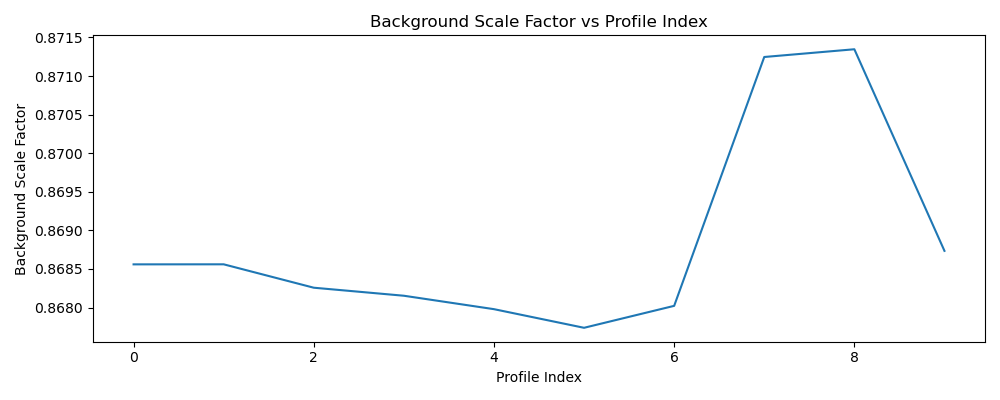

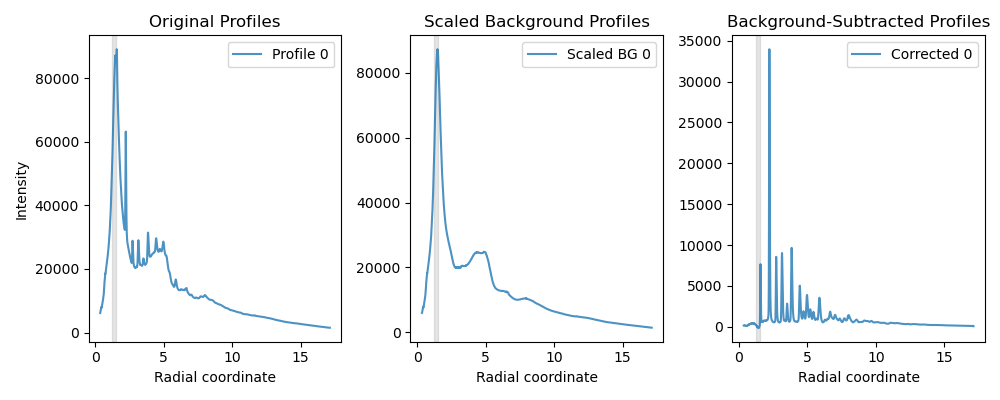

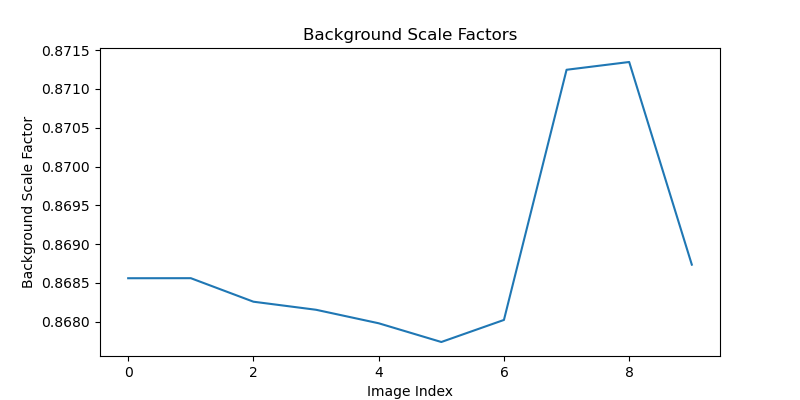

In [81]:
bgsub_result = trxrd.subtract_scaled_background_profile(
    radial=q,
    profiles=profiles,
    background_profile=background_profile,
    norm_range=(1.25, 1.5),   # example region; adjust as needed
    mode="mean",
    scale_method="ratio",
    plot=True,
    plot_scale_factors=True,
    plot_indices=[0],
    return_dict=True,
)

profiles_bgsub = bgsub_result["corrected_profiles"]
baselines = bgsub_result["scaled_background_profiles"]

# Inspect Scaling Factors
plt.figure(figsize=(8, 4))
plt.plot(bgsub_result["scale_factors"])
plt.xlabel("Image Index")
plt.ylabel("Background Scale Factor")
plt.title("Background Scale Factors")
plt.show()

## Save Background

In [82]:
df = pd.DataFrame({
    "q": q_bg,
    "I(q)": baselines[0]/1000   # example: save the baseline for the first image
})

df.to_csv(
    f"{SAVE_PATH}\{COMPOSITION}_360K_background.dat",
    sep=" ",
    index=False
)

## Subtract Baseline from Images

c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


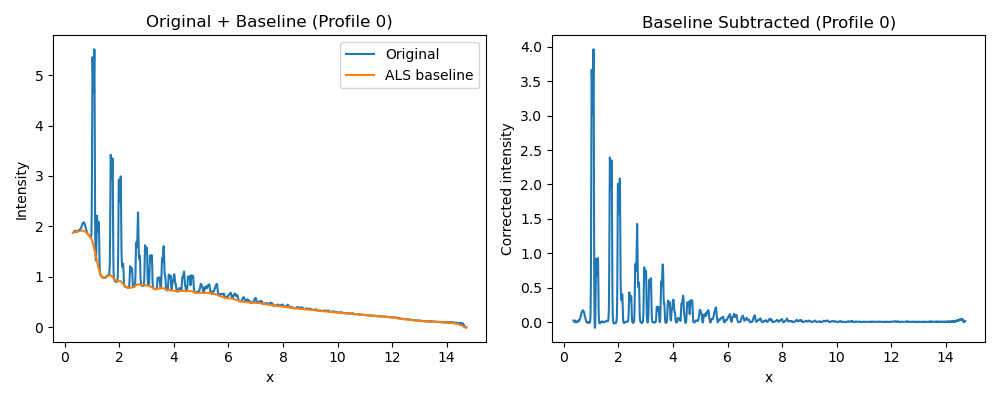

In [13]:
als_result = trxrd.subtract_als_baseline(
    data_array=profiles_norm,
    x_vals=q,
    lam=1e4,
    p=0.005,
    niter=10,
    plot=True,
    return_dict=True,
)

profiles_flat = als_result["corrected_data"]
baselines = als_result["baselines"]


In [14]:
np.savetxt(
    f"{SAVE_PATH}\CeO2_background.dat",
    np.column_stack((q, baselines[0])),  # example: save the first profile
    header="q(I) (1/A) I(q)",
    comments=""
)

## Compare with CIF File

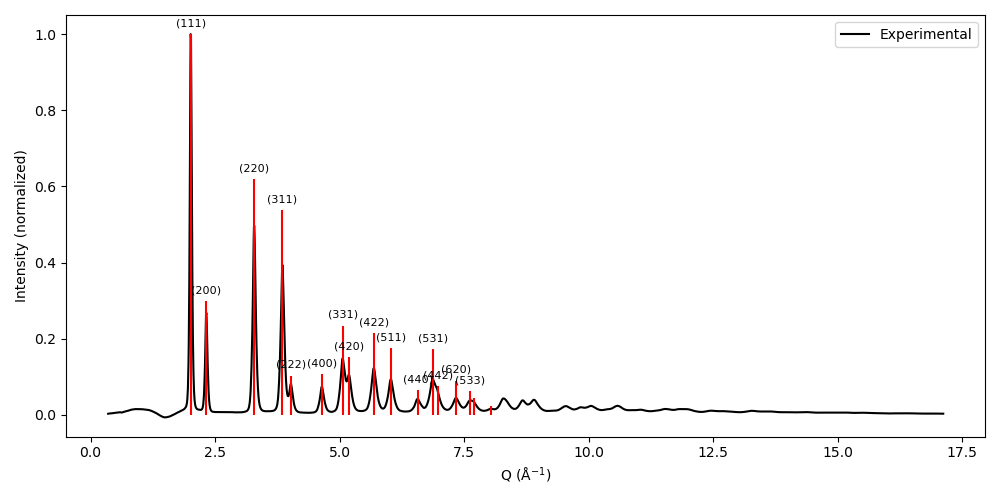

In [19]:
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

# Load structure
structure_path = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\output")
structure = Structure.from_file(structure_path / "CeO2_cubic.cif")

# Optionally override the lattice to literature value
structure.lattice = structure.lattice.from_parameters(
    a=5.4112, b=5.4112, c=5.4112, alpha=90, beta=90, gamma=90
)

# Compute pattern
wavelength = 0.39738
xrd = XRDCalculator(wavelength=wavelength)
two_theta_max = 30  # degrees, adjust to match your Q range

pattern = xrd.get_pattern(structure, two_theta_range=(0, two_theta_max))

# Convert to Q
two_theta = np.array(pattern.x)
intensity = np.array(pattern.y)
q_calc = 4 * np.pi * np.sin(np.deg2rad(two_theta) / 2) / wavelength

# Plot sticks alongside your experimental I(Q)
fig, ax = plt.subplots(figsize=(10, 5))

# Load your experimental I(Q) - replace with your actual file
q_exp = q
i_exp = profiles_bgsub[0]  # using the first profile as an example
mask = np.isfinite(q_exp) & np.isfinite(i_exp)
q_exp_clean = q_exp[mask]
i_exp_clean = i_exp[mask]
ax.plot(q_exp_clean, i_exp_clean / np.nanmax(i_exp_clean), 'k-', label='Experimental')

# Stick pattern, with hkl labels
for q_peak, i_peak, hkl_list in zip(q_calc, intensity, pattern.hkls):
    ax.vlines(q_peak, 0, i_peak / 100, color='red', linewidth=1.5)
    if i_peak > 5:  # only label significant peaks
        hkl = hkl_list[0]['hkl']
        ax.text(q_peak, i_peak/100 + 0.02, f'({hkl[0]}{hkl[1]}{hkl[2]})',
                ha='center', fontsize=8)

ax.set_xlabel(r'Q (Å$^{-1}$)')
ax.set_ylabel('Intensity (normalized)')
# ax.set_xlim(0, 8)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
from scipy.signal import find_peaks
peaks, properties = find_peaks(profiles_bgsub[0], height=1000)
x_positions = q[peaks]
print("Peak positions (Q):", x_positions)

Peak positions (Q): [1.57222122 2.22230006 2.7197517  3.14371616 3.51115203 3.8503236
 4.44387385 4.7152111  4.96958978 5.20700988 5.43312426 5.6648915
 5.8740473  6.65979477 7.02157778 7.34379077 7.35509649 7.68296234
 7.9542996  8.00517533]


## Save Background

In [16]:
df = pd.DataFrame({
    "q": q_bg,
    "I(q)": baselines[0]/1000   # example: save the baseline for the first image
})

df.to_csv(
    f"{SCAN_NAME}_background.dat",
    sep=" ",
    index=False
)